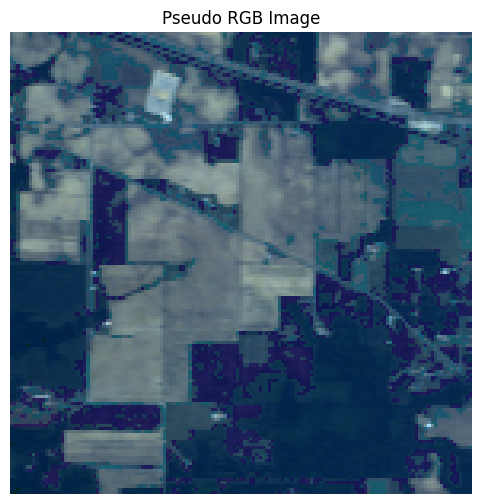

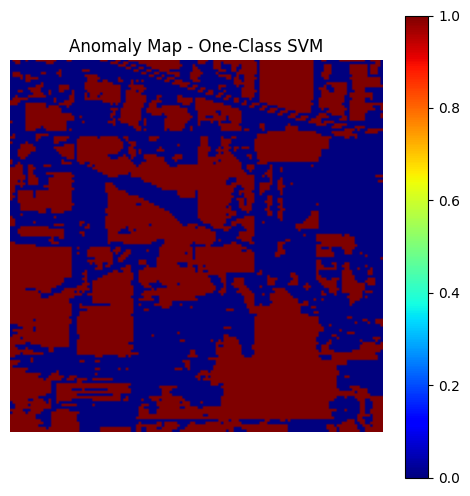

658/658 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


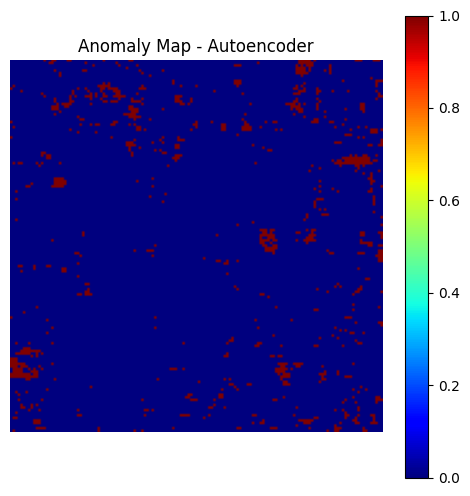

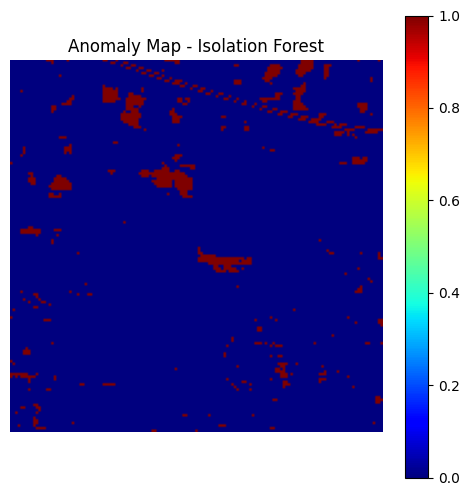

658/658 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


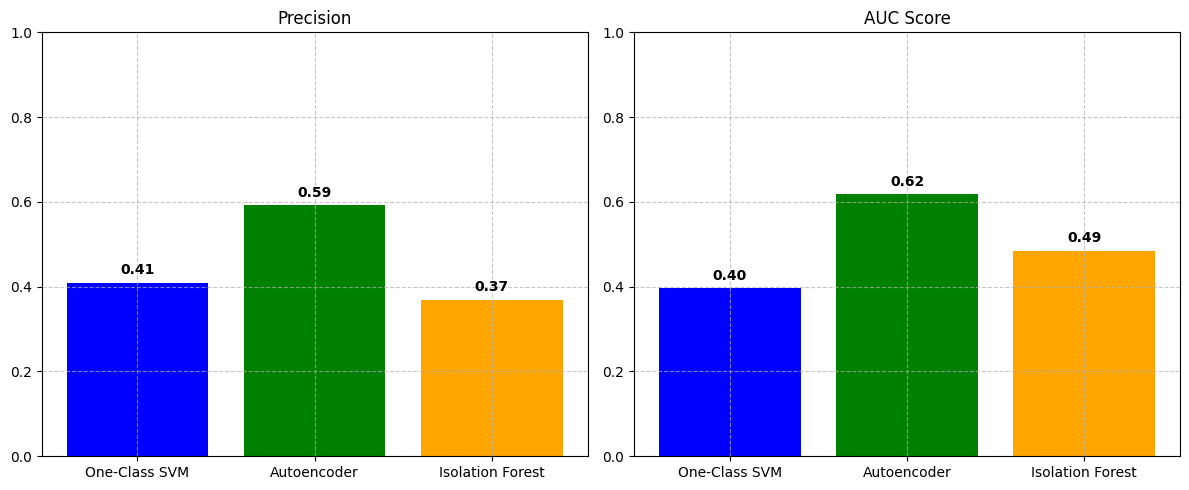

658/658 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


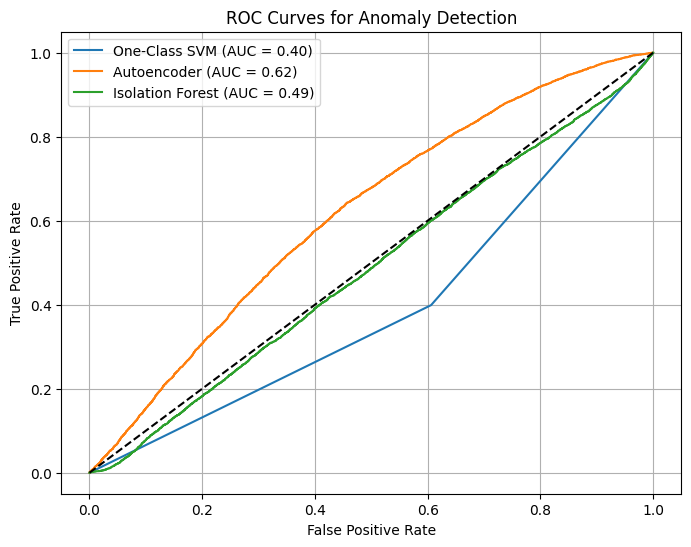

In [8]:
# ===============================
# STEP 1: Import Libraries
# ===============================
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score, roc_curve, auc, roc_auc_score
)
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import tensorflow as tf
import joblib

# ===============================
# STEP 2: Load Hyperspectral Data
# ===============================
def load_data():
    data = sio.loadmat("Indian_pines_corrected.mat")['indian_pines_corrected']
    labels = sio.loadmat("Indian_pines_gt.mat")['indian_pines_gt']
    return data, labels

# ===============================
# STEP 3: Preprocess Data
# ===============================
def preprocess_data(data, labels):
    h, w, bands = data.shape
    data = data.reshape(-1, bands)
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)
    return data, labels.reshape(-1), h, w, bands

# ===============================
# STEP 4: Train Models
# ===============================
def train_ocsvm(data):
    model = OneClassSVM(kernel='rbf', gamma='auto')
    model.fit(data)
    return model

def train_autoencoder(data, bands):
    input_layer = Input(shape=(bands,))
    encoded = Dense(128, activation='relu')(input_layer)
    encoded = Dense(64, activation='relu')(encoded)
    decoded = Dense(128, activation='relu')(encoded)
    decoded = Dense(bands, activation='sigmoid')(decoded)
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    autoencoder.fit(data, data, epochs=50, batch_size=256, shuffle=True, validation_split=0.1, verbose=0)
    return autoencoder

def train_isolation_forest(data):
    model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
    model.fit(data)
    return model

# ===============================
# STEP 5: Save Models
# ===============================
def save_models(ocsvm, autoencoder, iso_forest):
    joblib.dump(ocsvm, "ocsvm_model.pkl")
    autoencoder.save("autoencoder_model.h5")
    joblib.dump(iso_forest, "isolation_forest_model.pkl")

# ===============================
# STEP 6: Show RGB Image
# ===============================
def plot_rgb_image(data_cube):
    rgb = np.stack([
        data_cube[:, :, 29],  # R
        data_cube[:, :, 19],  # G
        data_cube[:, :, 9]    # B
    ], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.title("Pseudo RGB Image")
    plt.axis("off")
    plt.show()

# ===============================
# STEP 7: Anomaly Maps (Display Only)
# ===============================
def detect_anomalies(models, data, h, w):
    for name, model in models.items():
        if name == "One-Class SVM":
            y_pred = model.predict(data)
            anomaly_map = (y_pred == -1).astype(int).reshape(h, w)
        elif name == "Autoencoder":
            reconstructed = model.predict(data)
            errors = np.mean(np.abs(data - reconstructed), axis=1)
            threshold = np.percentile(errors, 95)
            anomaly_map = (errors > threshold).astype(int).reshape(h, w)
        elif name == "Isolation Forest":
            y_pred = model.predict(data)
            anomaly_map = (y_pred == -1).astype(int).reshape(h, w)

        plt.figure(figsize=(6, 6))
        plt.imshow(anomaly_map, cmap='jet')
        plt.colorbar()
        plt.title(f"Anomaly Map - {name}")
        plt.axis("off")
        plt.show()

# ===============================
# STEP 8: Evaluation
# ===============================
def evaluate_models(models, data, labels):
    true_anomalies = (labels == 0).astype(int)
    precision_scores, auc_scores = {}, {}

    for name, model in models.items():
        if name == "One-Class SVM":
            pred = (model.predict(data) == -1).astype(int)
            score = pred
        elif name == "Autoencoder":
            reconstructed = model.predict(data)
            errors = np.mean(np.abs(data - reconstructed), axis=1)
            threshold = np.percentile(errors, 95)
            pred = (errors > threshold).astype(int)
            score = errors
        elif name == "Isolation Forest":
            pred = (model.predict(data) == -1).astype(int)
            score = -model.decision_function(data)

        precision_scores[name] = precision_score(true_anomalies, pred, zero_division=0)
        try:
            auc_scores[name] = roc_auc_score(true_anomalies, score)
        except:
            auc_scores[name] = 0.0

    return precision_scores, auc_scores

# ===============================
# STEP 9: Plot Bar Graphs
# ===============================
def plot_comparisons(precision_scores, auc_scores):
    metrics = {
        "Precision": precision_scores,
        "AUC Score": auc_scores
    }

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs = axs.ravel()
    for i, (metric, scores) in enumerate(metrics.items()):
        names = list(scores.keys())
        values = list(scores.values())
        axs[i].bar(names, values, color=['blue', 'green', 'orange'])
        axs[i].set_ylim(0, 1)
        axs[i].set_title(metric)
        axs[i].grid(True, linestyle='--', alpha=0.7)
        for j, v in enumerate(values):
            axs[i].text(j, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

# ===============================
# STEP 10: Plot ROC Curves
# ===============================
def plot_roc(models, data, labels):
    true_anomalies = (labels == 0).astype(int)
    plt.figure(figsize=(8, 6))

    for name, model in models.items():
        if name == "One-Class SVM":
            score = (model.predict(data) == -1).astype(int)
        elif name == "Autoencoder":
            recon = model.predict(data)
            errors = np.mean(np.abs(data - recon), axis=1)
            score = errors
        elif name == "Isolation Forest":
            score = -model.decision_function(data)

        try:
            fpr, tpr, _ = roc_curve(true_anomalies, score)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
        except:
            pass

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Anomaly Detection')
    plt.legend()
    plt.grid()
    plt.show()

# ===============================
# STEP 11: Main Execution
# ===============================
data_cube, labels = load_data()
data, labels, h, w, bands = preprocess_data(data_cube, labels)

plot_rgb_image(data_cube)

ocsvm = train_ocsvm(data)
autoencoder = train_autoencoder(data, bands)
iso_forest = train_isolation_forest(data)

save_models(ocsvm, autoencoder, iso_forest)

models = {
    "One-Class SVM": ocsvm,
    "Autoencoder": autoencoder,
    "Isolation Forest": iso_forest
}

detect_anomalies(models, data, h, w)

precision_scores, auc_scores = evaluate_models(models, data, labels)

plot_comparisons(precision_scores, auc_scores)
plot_roc(models, data, labels)
